In [14]:
import h5py
import numpy as np
import tensorflow as tf

train_dataset = h5py.File('train_signs.h5', "r")
train_data = np.array(train_dataset["train_set_x"][:])
train_labels = np.array(train_dataset["train_set_y"][:]).reshape(-1, 1)

test_dataset = h5py.File('test_signs.h5', "r")
test_data = np.array(test_dataset["test_set_x"][:])
test_labels = np.array(test_dataset["test_set_y"][:]).reshape(-1, 1)
classes = np.array(test_dataset["list_classes"][:])

print(f"{train_data.shape}")
print(f"{train_labels.shape}")

(1080, 64, 64, 3)
(1080, 1)


In [15]:
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

dimData = 12288 
nClasses = 6    

model_signs = Sequential([
    Dense(512, activation='relu', input_shape=(dimData,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(nClasses, activation='softmax')
])

custom_optimizer = Adam(learning_rate=0.0001)
model_signs.compile(optimizer=custom_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

print("структура:")
model_signs.summary()


структура:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 512)                 │       6,291,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,424,838 (24.51 MB)

 Trainable params: 6,424,838 (24.51 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.utils import to_categorical
train_labels_one_hot = to_categorical(train_labels)
test_labels_one_hot = to_categorical(test_labels)
dimData = train_data.shape[1] * train_data.shape[2] * train_data.shape[3]
train_data_flat = train_data.reshape(train_data.shape[0], dimData).astype('float32') / 255
test_data_flat = test_data.reshape(test_data.shape[0], dimData).astype('float32') / 255

print("+")

+


Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.1852 - loss: 2.1765 - val_accuracy: 0.2667 - val_loss: 1.7382
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.1880 - loss: 1.8417 - val_accuracy: 0.2167 - val_loss: 1.7450
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.1926 - loss: 1.7820 - val_accuracy: 0.3417 - val_loss: 1.7166
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.2231 - loss: 1.7569 - val_accuracy: 0.4000 - val_loss: 1.7054
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.2352 - loss: 1.7420 - val_accuracy: 0.3333 - val_loss: 1.6957
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.2370 - loss: 1.7462 - val_accuracy: 0.2917 - val_loss: 1.7288
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.2611 - loss: 1.7296 - val_accuracy: 0.4000 - val_loss: 1.6704
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.2787 - loss: 1.6962 - val_accuracy: 0.3833 - v

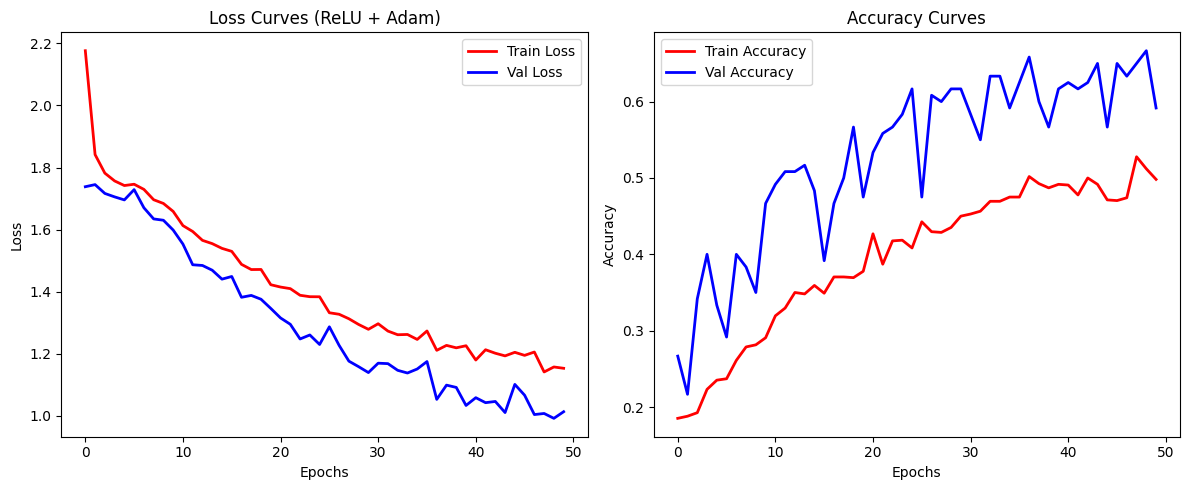

In [12]:
import matplotlib.pyplot as plt
history = model_signs.fit(
    train_data_flat, 
    train_labels_one_hot, 
    batch_size=32,  
    epochs=50,      
    verbose=1,
    validation_data=(test_data_flat, test_labels_one_hot)
)

[test_loss, test_acc] = model_signs.evaluate(test_data_flat, test_labels_one_hot, verbose=0)
print(f"Accuracy: {test_acc*100:.2f}% \n")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'r', label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], 'b', label='Val Loss', linewidth=2)
plt.title('Loss Curves (ReLU + Adam)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'r', label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], 'b', label='Val Accuracy', linewidth=2)
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.1731 - loss: 1.9116 - val_accuracy: 0.1667 - val_loss: 1.7825
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.1889 - loss: 1.8578 - val_accuracy: 0.1667 - val_loss: 1.7691
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.1852 - loss: 1.8499 - val_accuracy: 0.2833 - val_loss: 1.7466
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.2019 - loss: 1.8308 - val_accuracy: 0.4083 - val_loss: 1.7174
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.2102 - loss: 1.7984 - val_accuracy: 0.1917 - val_loss: 1.7110
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.2435 - loss: 1.7464 - val_accuracy: 0.4083 - val_loss: 1.6582
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.2620 - loss: 1.7368 - val_accuracy: 0.4250 - val_loss: 1.6264
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.2694 - loss: 1.6960 - val_accuracy: 0.5083 - v

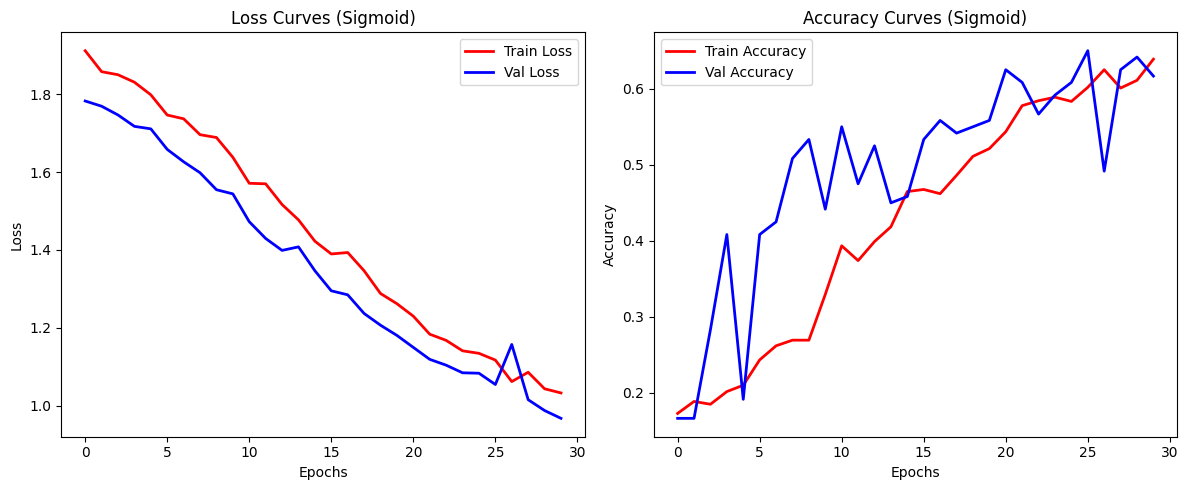

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

model_sigmoid = Sequential([
    Dense(512, activation='sigmoid', input_shape=(dimData,)),
    Dropout(0.3),
    Dense(256, activation='sigmoid'),
    Dropout(0.3),
    Dense(nClasses, activation='softmax')
])

model_sigmoid.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_sigmoid = model_sigmoid.fit(
    train_data_flat, 
    train_labels_one_hot, 
    batch_size=32,   
    epochs=30,       
    verbose=1,
    validation_data=(test_data_flat, test_labels_one_hot)
)


[test_loss, test_acc] = model_sigmoid.evaluate(test_data_flat, test_labels_one_hot, verbose=0)
print(f"SIGMOID): {test_acc*100:.2f}%\n")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_sigmoid.history['loss'], 'r', label='Train Loss', linewidth=2)
plt.plot(history_sigmoid.history['val_loss'], 'b', label='Val Loss', linewidth=2)
plt.title('Loss Curves (Sigmoid)')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sigmoid.history['accuracy'], 'r', label='Train Accuracy', linewidth=2)
plt.plot(history_sigmoid.history['val_accuracy'], 'b', label='Val Accuracy', linewidth=2)
plt.title('Accuracy Curves (Sigmoid)')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

dropout-0.5
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.1667 - loss: 2.3554 - val_accuracy: 0.2000 - val_loss: 1.7762
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.1657 - loss: 1.8203 - val_accuracy: 0.2417 - val_loss: 1.7808
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.1991 - loss: 1.7905 - val_accuracy: 0.1667 - val_loss: 1.7874
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.1528 - loss: 1.7926 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.1620 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.1713 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.1630 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.1685 - loss: 1.7918 - val_accuracy

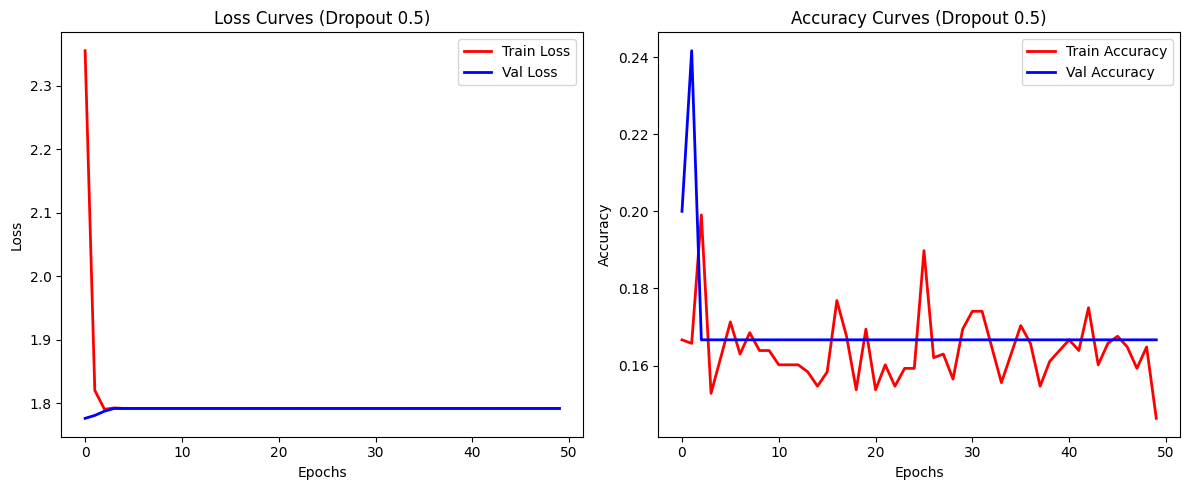

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print("dropout-0.5")
model_dropout = Sequential([
    Dense(512, activation='relu', input_shape=(dimData,)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(nClasses, activation='softmax')
])

model_dropout.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_dropout = model_dropout.fit(
    train_data_flat, 
    train_labels_one_hot, 
    batch_size=32,   
    epochs=50,       
    verbose=1,
    validation_data=(test_data_flat, test_labels_one_hot)
)

[test_loss, test_acc] = model_dropout.evaluate(test_data_flat, test_labels_one_hot, verbose=0)
print(f"Dropout 0.5: {test_acc*100:.2f}%\n")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['loss'], 'r', label='Train Loss', linewidth=2)
plt.plot(history_dropout.history['val_loss'], 'b', label='Val Loss', linewidth=2)
plt.title('Loss Curves (Dropout 0.5)')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['accuracy'], 'r', label='Train Accuracy', linewidth=2)
plt.plot(history_dropout.history['val_accuracy'], 'b', label='Val Accuracy', linewidth=2)
plt.title('Accuracy Curves (Dropout 0.5)')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()